In [9]:
import numpy as np
import pandas as pd

In [ ]:
data = pd.read_csv('logs/session_20250819-384-6/session.csv')
data.head()

,request_arrival_time,response_output_time,preprocess_start_time,inference_start_time,inference_end_time,postprocess_start_time,round_trip_time,server_processing_duration,total_network_latency
0,2.001373e+06,2.001373e+06,2.001373e+06,2.001373e+06,2.001373e+06,2.001373e+06,0.808430,0.796760,0.011670
1,2.001373e+06,2.001374e+06,2.001373e+06,2.001373e+06,2.001374e+06,2.001374e+06,0.245498,0.241960,0.003537
2,2.001374e+06,2.001374e+06,2.001374e+06,2.001374e+06,2.001374e+06,2.001374e+06,0.282907,0.279442,0.003466
3,2.001374e+06,2.001374e+06,2.001374e+06,2.001374e+06,2.001374e+06,2.001374e+06,0.301630,0.297666,0.003964
4,2.001374e+06,2.001374e+06,2.001374e+06,2.001374e+06,2.001374e+06,2.001374e+06,0.242780,0.238874,0.003906


In [11]:
# Calculate the duration of each stage by finding the difference between timestamps
data['server_total_duration'] = data['response_output_time'] - data['request_arrival_time']
data['server_preprocess_duration'] = data['inference_start_time'] - data['preprocess_start_time']
data['inference_duration'] = data['inference_end_time'] - data['inference_start_time']
data['server_postprocess_duration'] = data['response_output_time'] - data['postprocess_start_time']
data['request_send_duration'] = data['request_arrival_time'] - data['preprocess_start_time']


# This represents network latency plus any other time not captured by the server's timestamps.
data['network_and_other_latency'] = data['round_trip_time'] - data['server_total_duration']
data['response_receive_duration'] = data['network_and_other_latency'] - data['request_send_duration']

# Create a new DataFrame containing only the calculated durations for clarity
durations_df = data[[
    'round_trip_time',
    'server_total_duration',
    'inference_duration',
    'server_preprocess_duration',
    'server_postprocess_duration',
    'request_send_duration',
    'response_receive_duration',
    'network_and_other_latency'
]]

# Display the calculated durations for each inference request
print("Calculated Durations for Each Request (in seconds):")
display(durations_df.head())

# Display summary statistics (mean, std, min, max, etc.) for these durations
print("\nSummary Statistics for Durations (in seconds):")
display(durations_df.describe())

Calculated Durations for Each Request (in seconds):


,round_trip_time,server_total_duration,inference_duration,server_preprocess_duration,server_postprocess_duration,request_send_duration,response_receive_duration,network_and_other_latency
0,0.808430,0.796760,0.639108,0.156678,0.000960,-0.000013,0.011683,0.011670
1,0.245498,0.241960,0.238970,0.002256,0.000731,-0.000003,0.003540,0.003537
2,0.282907,0.279442,0.277256,0.001308,0.000876,-0.000002,0.003468,0.003466
3,0.301630,0.297666,0.295361,0.001381,0.000921,-0.000003,0.003967,0.003964
4,0.242780,0.238874,0.236645,0.001411,0.000817,-0.000002,0.003908,0.003906



Summary Statistics for Durations (in seconds):


,round_trip_time,server_total_duration,inference_duration,server_preprocess_duration,server_postprocess_duration,request_send_duration,response_receive_duration,network_and_other_latency
count,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000
mean,0.255891,0.251712,0.247763,0.002747,0.001186,-0.000017,0.004195,0.004178
std,0.051113,0.050727,0.043135,0.010779,0.000203,0.000019,0.000599,0.000597
min,0.207405,0.203015,0.200096,0.001308,0.000731,-0.000097,0.003468,0.003466
25%,0.221106,0.216833,0.213840,0.001890,0.001020,-0.000028,0.003968,0.003962
50%,0.248664,0.244553,0.241265,0.002008,0.001142,-0.000003,0.004138,0.004113
75%,0.281118,0.276969,0.273423,0.002114,0.001378,-0.000003,0.004346,0.004335
max,0.808430,0.796760,0.639108,0.156678,0.001727,-0.000002,0.011683,0.011670


Summary Statistics for Durations (in seconds):


,round_trip_time,server_processing_duration,total_network_latency,inference_duration,server_preprocess_duration,server_postprocess_duration
count,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000
mean,0.255891,0.251712,0.004178,0.247763,0.002747,0.001186
std,0.051113,0.050727,0.000597,0.043135,0.010779,0.000203
min,0.207405,0.203015,0.003466,0.200096,0.001308,0.000731
25%,0.221106,0.216833,0.003962,0.213840,0.001890,0.001020
50%,0.248664,0.244553,0.004113,0.241265,0.002008,0.001142
75%,0.281118,0.276969,0.004335,0.273423,0.002114,0.001378
max,0.808430,0.796760,0.011670,0.639108,0.156678,0.001727


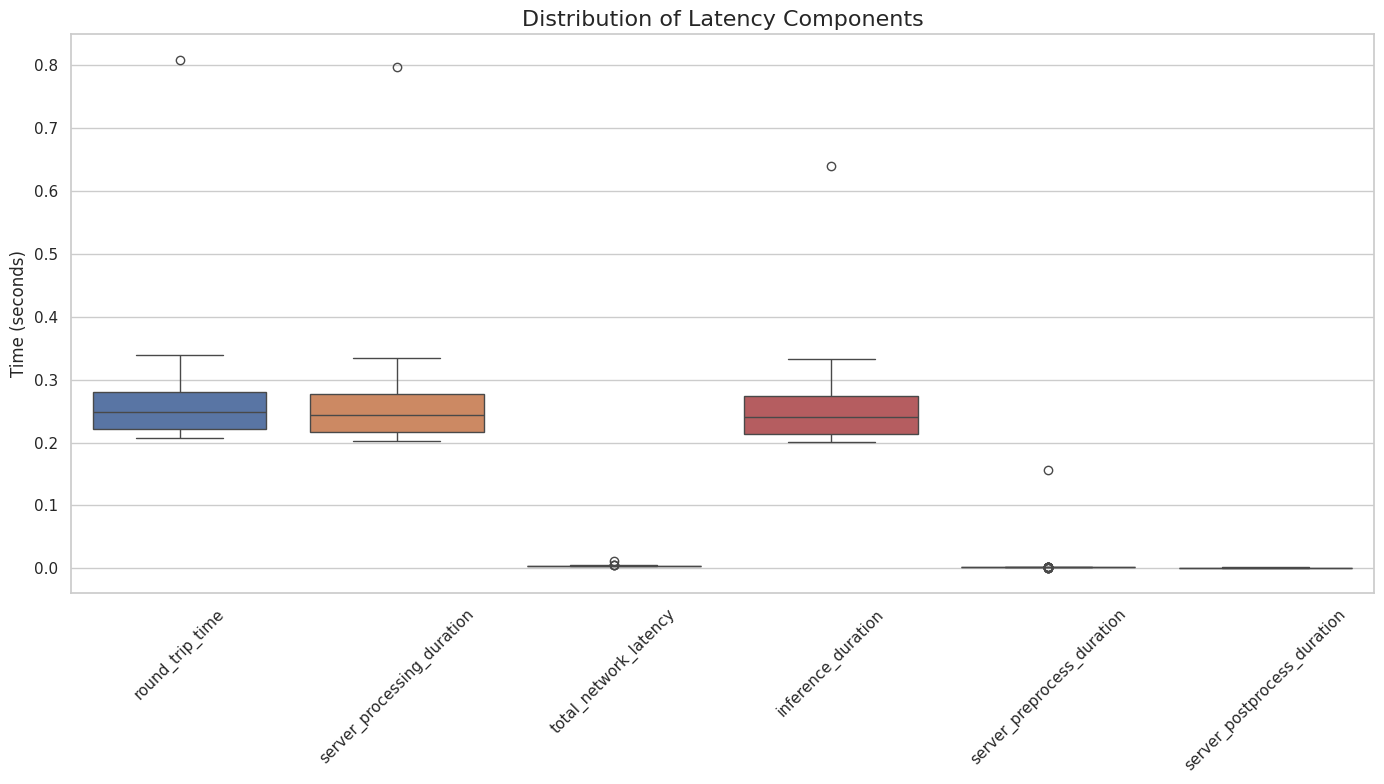

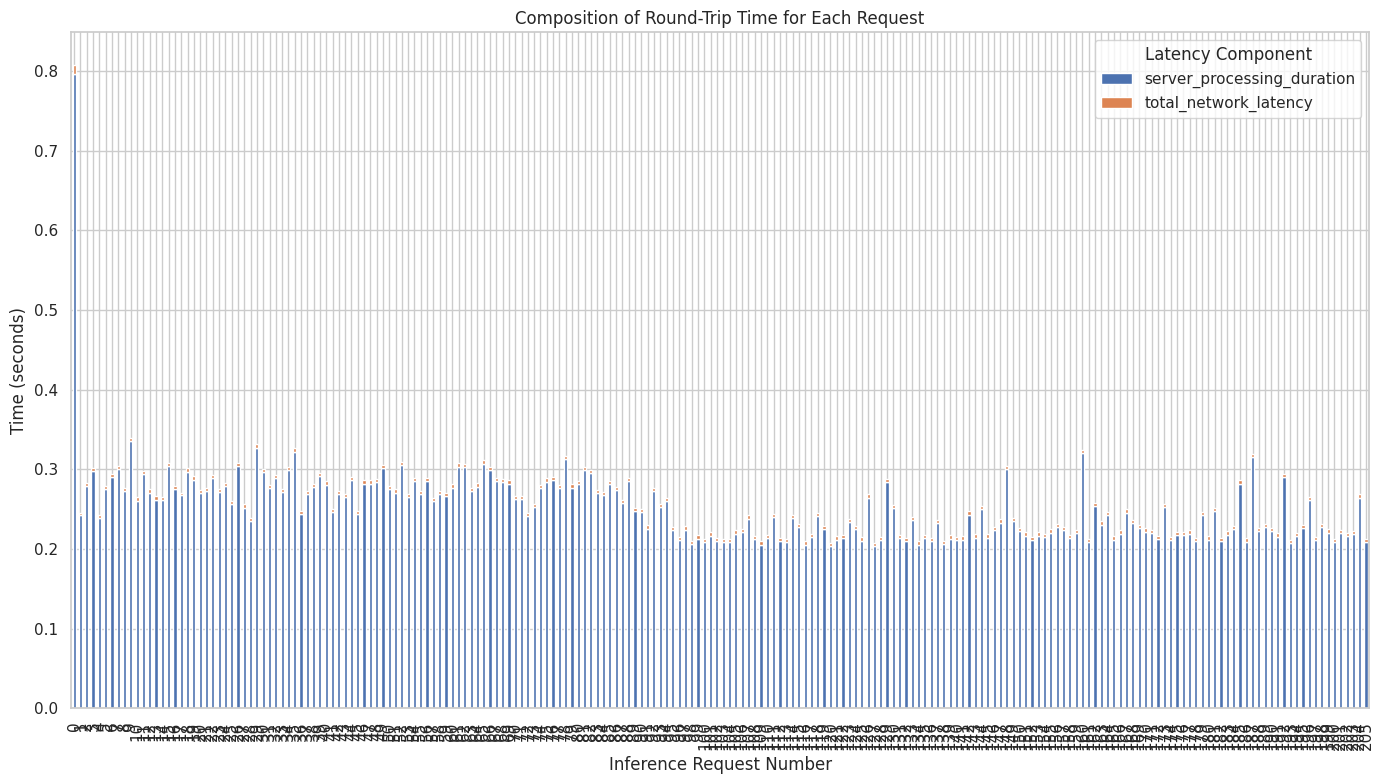

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the duration of each stage by finding the difference between timestamps
data['inference_duration'] = data['inference_end_time'] - data['inference_start_time']
data['server_preprocess_duration'] = data['inference_start_time'] - data['preprocess_start_time']
data['server_postprocess_duration'] = data['response_output_time'] - data['postprocess_start_time']


# Create a new DataFrame containing only the calculated durations for clarity
durations_df = data[[
    'round_trip_time',
    'server_processing_duration',
    'total_network_latency',
    'inference_duration',
    'server_preprocess_duration',
    'server_postprocess_duration',
    
]].copy()

# Display summary statistics (mean, std, min, max, etc.) for these durations
print("Summary Statistics for Durations (in seconds):")
display(durations_df.describe())

# --- Visualization ---

# Set up the plot style
sns.set_theme(style="whitegrid")

# Create a boxplot to see the distribution of each latency component
plt.figure(figsize=(14, 8))
sns.boxplot(data=durations_df)
plt.xticks(rotation=45)
plt.title('Distribution of Latency Components', fontsize=16)
plt.ylabel('Time (seconds)')
plt.tight_layout()
plt.show()

# Create a stacked bar chart to show the composition of the round-trip time
plot_data = durations_df[[
    'server_processing_duration',
    'total_network_latency'
]].copy()
plot_data.reset_index(inplace=True) # Use the request number as the x-axis

plot_data.plot(
    x='index',
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    title='Composition of Round-Trip Time for Each Request'
)
plt.xlabel("Inference Request Number")
plt.ylabel("Time (seconds)")
plt.legend(title='Latency Component')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3546345/754132906.py:85: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_duration = left_values[0]


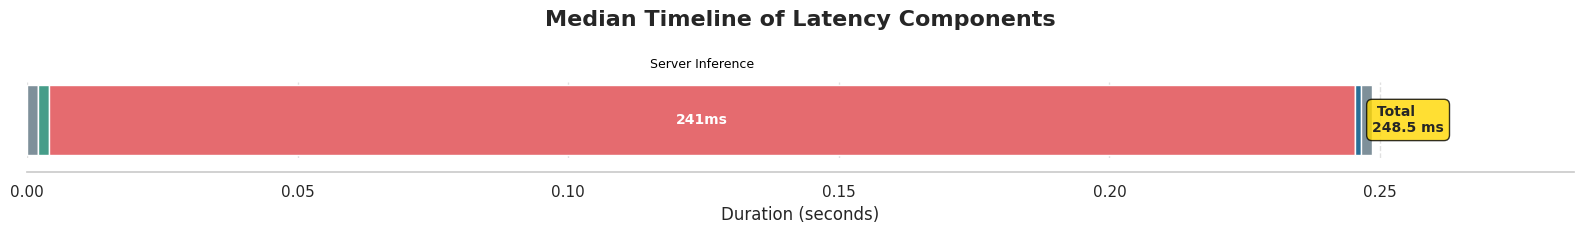

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time

# --- 1. Load Data ---
# Replace with the actual path to your session log CSV file.
csv_path = 'logs/session_20250819-384-6/session.csv' 
try:
    results_df = pd.read_csv(csv_path)
except FileNotFoundError:
    print(f"Error: CSV file not found at '{csv_path}'")
    print("Please update the 'csv_path' variable with the correct file path.")
    # As a fallback, create a dummy dataframe for demonstration purposes.
    num_samples = 50
    base_time = time.time()
    latency_data = {}
    latency_data['total_network_latency'] = np.random.normal(0.02, 0.005, num_samples)
    latency_data['request_arrival_time'] = base_time + latency_data['total_network_latency'] / 2
    latency_data['preprocess_start_time'] = latency_data['request_arrival_time'] + np.random.normal(0.002, 0.0005, num_samples)
    latency_data['inference_start_time'] = latency_data['preprocess_start_time'] + np.random.normal(0.015, 0.003, num_samples)
    latency_data['inference_end_time'] = latency_data['inference_start_time'] + np.random.normal(0.120, 0.01, num_samples)
    latency_data['postprocess_start_time'] = latency_data['inference_end_time'] + np.random.normal(0.001, 0.0002, num_samples)
    latency_data['response_output_time'] = latency_data['postprocess_start_time'] + np.random.normal(0.010, 0.002, num_samples)
    results_df = pd.DataFrame(latency_data)
    print("\nNOTE: Using dummy data for demonstration.")

# --- 2. Calculate Timeline Component Durations ---
durations_df = pd.DataFrame()
durations_df['Network (Request)'] = results_df['total_network_latency'] / 2
durations_df['Server Overhead (Pre)'] = results_df['preprocess_start_time'] - results_df['request_arrival_time']
durations_df['Server Pre-processing'] = results_df['inference_start_time'] - results_df['preprocess_start_time']
durations_df['Server Inference'] = results_df['inference_end_time'] - results_df['inference_start_time']
durations_df['Server Overhead (Post)'] = results_df['postprocess_start_time'] - results_df['inference_end_time']
durations_df['Server Post-processing'] = results_df['response_output_time'] - results_df['postprocess_start_time']
durations_df['Network (Response)'] = results_df['total_network_latency'] / 2

# --- 3. Get Median Statistics ---
# We calculate the median for a robust view.
median_durations = durations_df.median()
stats_df = pd.DataFrame([median_durations], index=['Median'])

# Define the order for plotting to match the timeline of events.
component_order = [
    'Network (Request)',
    'Server Overhead (Pre)',
    'Server Pre-processing',
    'Server Inference',
    'Server Overhead (Post)',
    'Server Post-processing',
    'Network (Response)'
]
stats_df = stats_df[component_order]

# --- 4. Create Visualization ---
fig, ax = plt.subplots(figsize=(16, 2.5))
ax.set_title('Median Timeline of Latency Components', fontsize=16, fontweight='bold', pad=40)

# Define colors for each component
colors = {
    'Network (Request)': '#7E909A', 'Server Overhead (Pre)': '#D4C685',
    'Server Pre-processing': '#469D89', 'Server Inference': '#E56B6F',
    'Server Overhead (Post)': '#D4C685', 'Server Post-processing': '#2A6F97',
    'Network (Response)': '#7E909A'
}
component_colors = [colors[comp] for comp in component_order]

# Use a loop to create the stacked horizontal bars
left_values = np.zeros(len(stats_df))
for i, component in enumerate(stats_df.columns):
    values = stats_df[component]
    bars = ax.barh(stats_df.index, values, left=left_values, height=0.5, color=component_colors[i], edgecolor='white')
    
    # Add duration text inside each segment and component label above
    for j, (bar, val, left) in enumerate(zip(bars, values, left_values)):
        if bar.get_width() > 0.003:
            # Duration text inside the bar
            ax.text(left + val / 2, j, f'{val*1000:.0f}ms', ha='center', va='center', color='white', fontsize=10, fontweight='bold')
            # Component label above the bar
            ax.text(left + val / 2, j + 0.35, component.replace(" ", " "), ha='center', va='bottom', color='black', fontsize=9, linespacing=1)
            
    left_values += values

# Add a total duration label at the end of the bar
total_duration = left_values[0]
ax.text(total_duration, 0, f' Total\n{total_duration*1000:.1f} ms', ha='left', va='center', 
        fontweight='bold', fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", fc='gold', ec='black', lw=1, alpha=0.8))

# --- Formatting ---
ax.set_xlabel('Duration (seconds)', fontsize=12)
ax.set_yticklabels([]) # Hide y-axis label
ax.set_yticks([])     # Hide y-axis ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_position(('outward', 10))
ax.grid(axis='x', linestyle='--', alpha=0.6)

# Set the x-axis limits to provide some padding
plt.xlim(0, total_duration * 1.15)

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import re

def analyze_results(results_path, parameter_name, x_axis_label, lock):
    """
    Loads all benchmark CSVs from a path, calculates mean latencies,
    and plots the results.
    """
    all_files = glob.glob(os.path.join(results_path, "*.csv"))
    
    summary_data = []

    for f in all_files:
        # Extract the parameter value from the filename
        prompt_len = int(f.split('_')[1].split('.')[0])
        gen_len = int(f.split('_')[-1].split('.')[0])
        if lock == 'gen':
            if prompt_len != 96:
                continue
            param_value = gen_len
        elif lock == 'prompt':
            if gen_len != 16:
                continue
            param_value = prompt_len
        else:
            break
        
        type = f.split('_')[-1].split('.')[1]
        if type != 'csv':
            continue
        
        
        # Read the data and calculate median latencies
        df = pd.read_csv(f)
        median_round_trip = df['round_trip_time'].median()
        median_inference = df['inference_duration'].median()
        median_network_latency = df['total_network_latency'].median()
        
        summary_data.append({
            parameter_name: param_value,
            'median_round_trip_time': median_round_trip,
            'median_inference_duration': median_inference,
            'median_network_latency': median_network_latency
        })

    if not summary_data:
        print(f"No result files found in '{results_path}'. Please check the path and filenames.")
        return

    # Create a DataFrame and sort by the parameter value
    summary_df = pd.DataFrame(summary_data).sort_values(by=parameter_name)
    # display(summary_df)
    
    # --- Plotting ---
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(summary_df[parameter_name], summary_df['median_round_trip_time'], marker='o', linestyle='-', label='Median Round-Trip Time')
    ax.plot(summary_df[parameter_name], summary_df['median_inference_duration'], marker='x', linestyle='--', label='Median Inference Duration')
    ax.plot(summary_df[parameter_name], summary_df['median_network_latency'], marker='x', linestyle='--', label='Median Network Latency')

    ax.set_title(f'Server Latency vs. {x_axis_label}', fontsize=16)
    ax.set_xlabel(x_axis_label, fontsize=12)
    ax.set_ylabel('Median Latency (seconds)', fontsize=12)
    ax.legend()
    ax.grid(True)
    
    plt.show()


# --- Run the analysis for your two experiments ---

# IMPORTANT: Make sure your CSV files are named like 'gen_len_8.csv', 'prompt_len_48.csv', etc.
# And they are all inside a 'results/' directory in your project root.

# 1. Analyze Generation Length Results
# Assumes your files for this experiment start with "gen_len_"
analyze_results('results', 'prompt_96_gen', 'Generation Length (Frames)', 'gen')

# 2. Analyze Prompt Length Results
# Assumes your files for this experiment start with "prompt_len_"
analyze_results('results', 'prompt_length', 'Prompt Length (Frames)', 'prompt')


No result files found in 'results'. Please check the path and filenames.
No result files found in 'results'. Please check the path and filenames.
